In [6]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
ramData = pd.read_csv('RAM_Benchmarks_megalist.csv')
ramData.head()

,memoryName,gen,latency,readUncached,write,price
0,Kingston KF556C40-32 32GB,DDR5,44,21600.0,18100.0,NaN
1,G Skill Intl F5-6400J3239G16G 16GB,DDR5,31,19500.0,16700.0,909.98
2,G Skill Intl F5-5600J3636C16G 16GB,DDR5,42,19400.0,16300.0,627.98
3,G Skill Intl F5-6000U3636E16G 16GB,DDR5,28,18700.0,15900.0,NaN
4,Corsair CMT64GX5M2B5200C40 32GB,DDR5,37,16500.0,15400.0,NaN


In [8]:
ramData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10855 entries, 0 to 10854
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   memoryName    10855 non-null  object 
 1   gen           10855 non-null  object 
 2   latency       10855 non-null  int64  
 3   readUncached  10855 non-null  float64
 4   write         10855 non-null  float64
 5   price         1456 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 509.0+ KB


In [9]:
ramData.describe()

,latency,readUncached,write,price
count,10855.000000,10855.000000,10855.000000,1456.000000
mean,41.794012,11691.709857,8134.654473,165.034478
std,20.238743,5415.005883,4565.178282,191.326363
min,14.000000,66.300000,246.100000,6.000000
25%,27.000000,6168.750000,3800.000000,41.990000
50%,34.000000,13300.000000,8400.000000,96.960000
75%,53.000000,15800.000000,11500.000000,203.807500
max,374.000000,26400.000000,22200.000000,999.990000


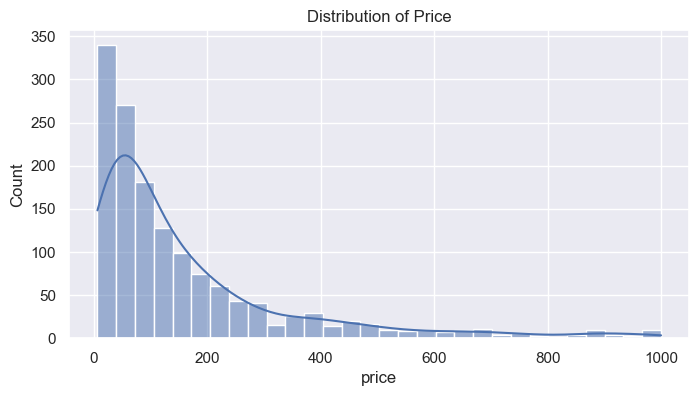

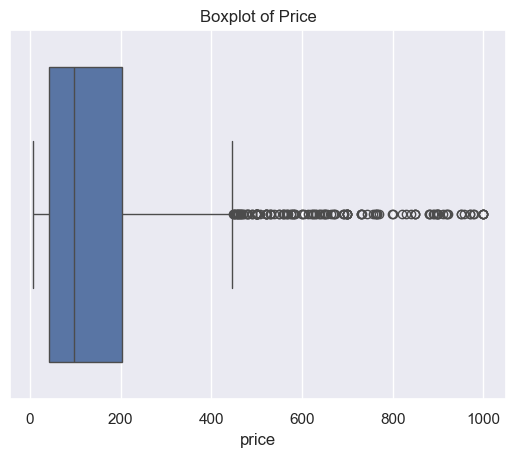

In [16]:

# 2. Plot a histogram of the 'price' column to see its distribution
plt.figure(figsize=(8, 4))
sb.histplot(ramData['price'].dropna(), kde=True, bins=30)
plt.title('Distribution of Price')
plt.show()

# 3. Use a Boxplot to easily spot outliers
sb.boxplot(x=ramData['price'])
plt.title('Boxplot of Price')
plt.show()

In [17]:
clean_ramData = ramData.dropna(subset=['price'])
clean_ramData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 1 to 10839
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   memoryName    1456 non-null   object 
 1   gen           1456 non-null   object 
 2   latency       1456 non-null   int64  
 3   readUncached  1456 non-null   float64
 4   write         1456 non-null   float64
 5   price         1456 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 79.6+ KB


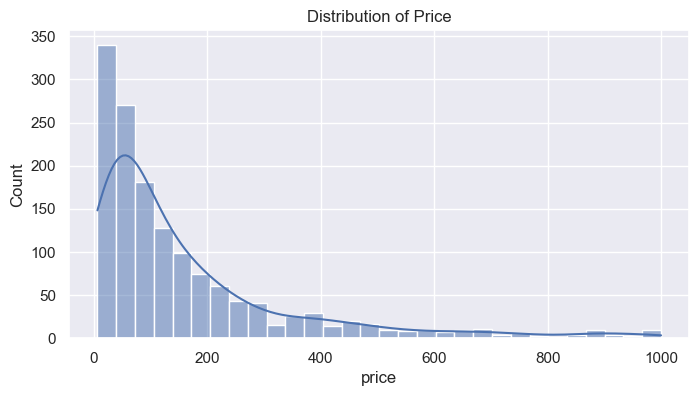

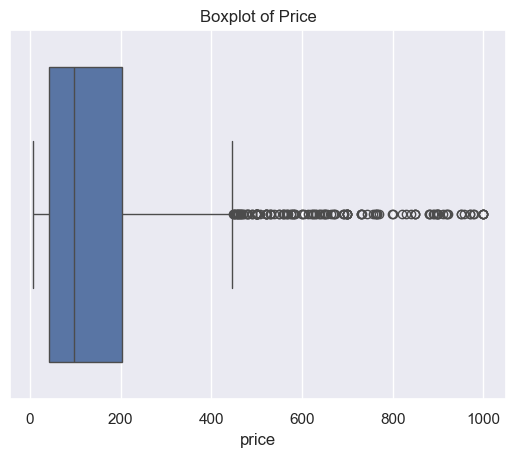

In [18]:
plt.figure(figsize=(8, 4))
sb.histplot(clean_ramData['price'].dropna(), kde=True, bins=30)
plt.title('Distribution of Price')
plt.show()

# 3. Use a Boxplot to easily spot outliers
sb.boxplot(x=clean_ramData['price'])
plt.title('Boxplot of Price')
plt.show()

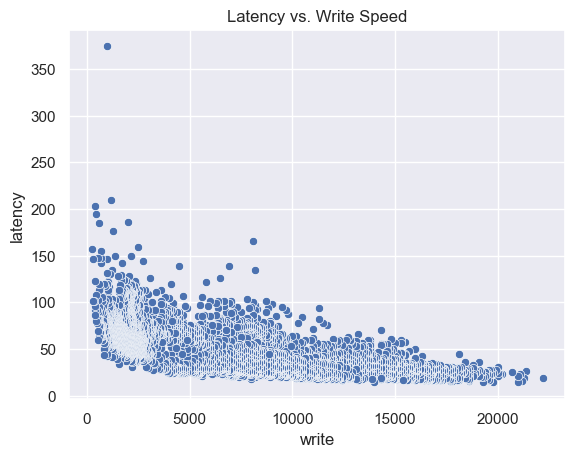

ValueError: could not convert string to float: 'Kingston KF556C40-32 32GB'

In [20]:
# 1. Scatter plot to see the relationship between latency and write
sb.scatterplot(data=energyData, x='write', y='latency')
plt.title('Latency vs. Write Speed')
plt.show()

# 2. Correlation Matrix (measures linear relationships on a scale of -1 to 1)
# Closer to 1 or -1 means a strong relationship; closer to 0 means no relationship.
corr_matrix = energyData.corr()
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [22]:
# Define a cutoff at the 99th percentile
price_cutoff = ramData['price'].quantile(0.99)

# Flag anything above this threshold
extreme_prices = ramData[ramData['price'] > price_cutoff]

print(f"Any price above {price_cutoff:.2f} is considered an anomaly.")

Any price above 913.58 is considered an anomaly.


In [25]:
from sklearn.cluster import KMeans
import numpy as np

features = ["write", "latency", "price"]
df_clean = ramData.dropna(subset=features).copy()

# 2. Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_clean[features])

# 3. Calculate distance to nearest cluster center
distances = kmeans.transform(df_clean[features])
min_distances = np.min(distances, axis=1)

# 4. Flag the top 1% farthest points as anomalies
threshold = np.percentile(min_distances, 99)
anomalies = df_clean[min_distances > threshold]

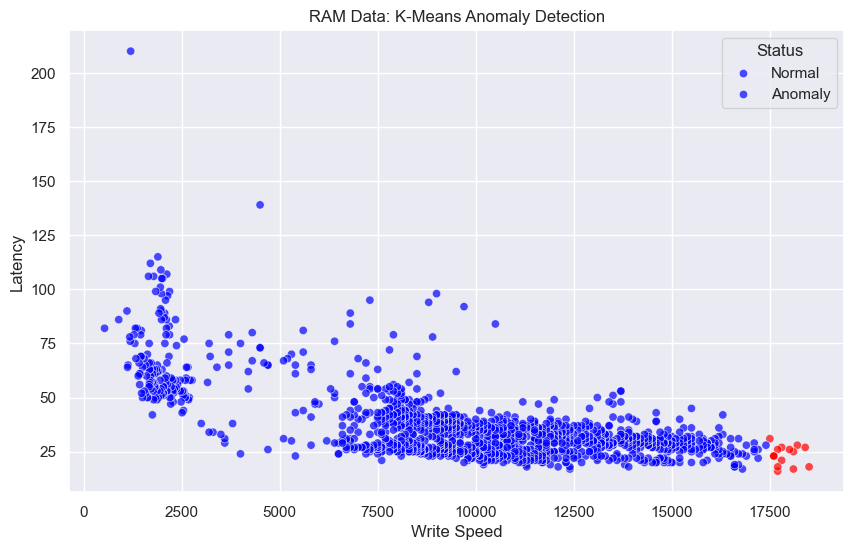

In [26]:
df_clean["is_anomaly"] = np.where(min_distances > threshold, 1, 0)

# 2. Plot Latency vs. Write Speed, coloring by anomaly status
plt.figure(figsize=(10, 6))
sb.scatterplot(
    data=df_clean,
    x="write",
    y="latency",
    hue="is_anomaly",
    palette={0: "blue", 1: "red"},
    alpha=0.7,
)

plt.title("RAM Data: K-Means Anomaly Detection")
plt.xlabel("Write Speed")
plt.ylabel("Latency")
plt.legend(title="Status", labels=["Normal", "Anomaly"])
plt.show()

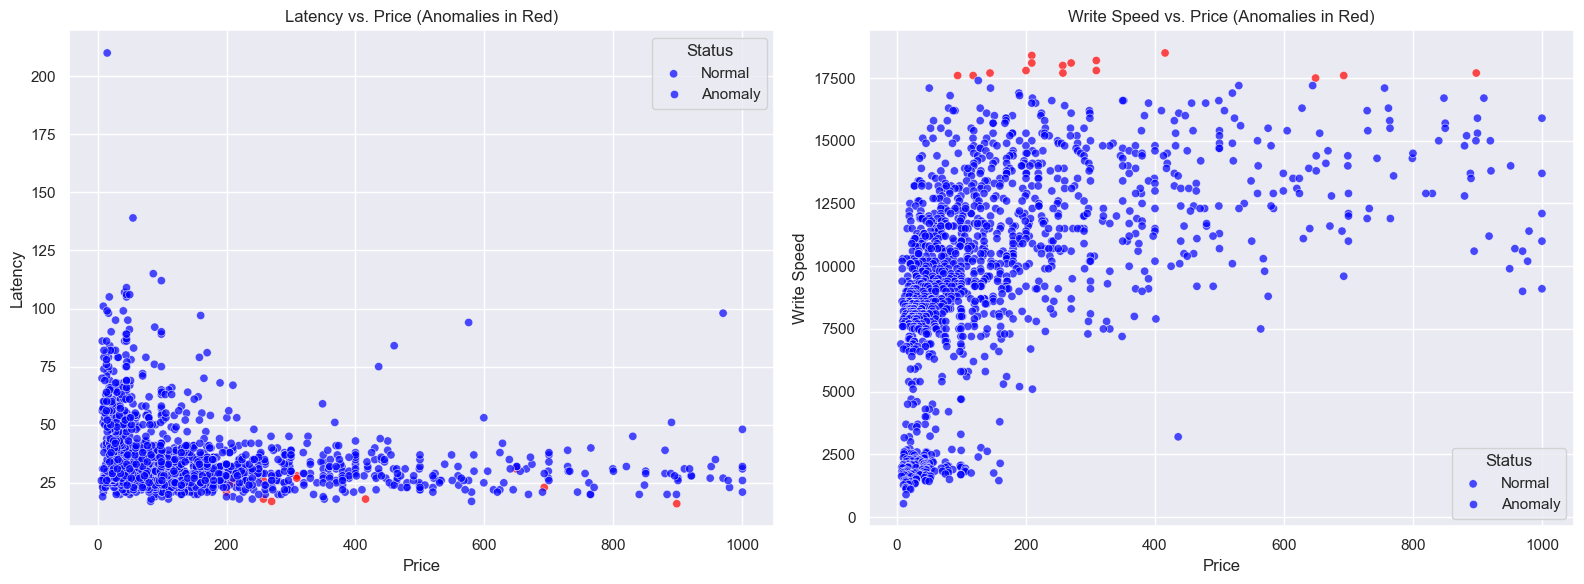

In [27]:

from sklearn.cluster import KMeans

# 1. Clean the data (keep only rows where all 3 metrics exist)
features = ["write", "latency", "price"]
df_clean = ramData.dropna(subset=features).copy()

# 2. Fit K-Means on the 3D space
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_clean[features])

# 3. Calculate distance to find the top 1% anomalies
distances = kmeans.transform(df_clean[features])
min_distances = np.min(distances, axis=1)
threshold = np.percentile(min_distances, 99)

# Add anomaly label to our dataframe (1 = Anomaly, 0 = Normal)
df_clean["is_anomaly"] = np.where(min_distances > threshold, 1, 0)

# 4. Set up a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graph 1: Latency vs. Price ---
sb.scatterplot(
    data=df_clean,
    x="price",
    y="latency",
    hue="is_anomaly",
    palette={0: "blue", 1: "red"},
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title("Latency vs. Price (Anomalies in Red)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Latency")
axes[0].legend(title="Status", labels=["Normal", "Anomaly"])

# --- Graph 2: Write Speed vs. Price ---
sb.scatterplot(
    data=df_clean,
    x="price",
    y="write",
    hue="is_anomaly",
    palette={0: "blue", 1: "red"},
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title("Write Speed vs. Price (Anomalies in Red)")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Write Speed")
axes[1].legend(title="Status", labels=["Normal", "Anomaly"])

plt.tight_layout()
plt.show()